<a href="https://colab.research.google.com/github/golamrabbanirifat41/BRACU-Masters-Projects/blob/main/Learning_and_Planning_with_Dyna_Q_cse753_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating figs folder

In [ ]:
!mkdir -p figs

In [ ]:
%%writefile envs.py


"""
Grid-world maze environments for Dyna-Q experiments.

Four environments, all deterministic*, episodic gridworlds with a single
goal cell and blocked "wall" cells the agent cannot enter:

1. DynaMaze        - static walls (never change). Used to compare the effect
                      of the planning-step count n on learning speed.
2. BlockingMaze    - the wall configuration CHANGES ONCE at a fixed timestep,
                      closing off the agent's previously-optimal path and
                      forcing it to find a new, longer one. Tests whether an
                      agent notices the environment got WORSE.
3. ShortcutMaze    - the wall configuration CHANGES ONCE at a fixed timestep,
                      opening up a new, shorter path. Tests whether an agent
                      notices the environment got BETTER (classic Dyna-Q+
                      motivating example).
4. FlickeringMaze  - a *repeatedly* changing environment: one interior wall
                      cell toggles open/closed on a fixed period throughout
                      the whole run (not just once). This is a qualitatively
                      different kind of non-stationarity from #2/#3 (ongoing
                      vs. one-off change) and gives us a genuinely distinct
                      third dynamic environment.

*Transitions are deterministic given the current wall configuration; the
configuration itself is a deterministic function of the timestep.

All four share the same MDP structure (see report for full formalism):
  - State s = (row, col) on an integer grid
  - Actions A = {up, down, left, right}
  - Deterministic transition: moving into a wall cell or off the grid
    leaves the agent in place; otherwise it moves one cell.
  - Reward: 0 on every step, +1 on entering the goal cell, episode ends.
  - Discount gamma = 1.0 (episodic, undiscounted, matches Sutton & Barto).
"""

import numpy as np

UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
ACTIONS = [UP, DOWN, LEFT, RIGHT]
ACTION_DELTAS = {UP: (-1, 0), DOWN: (1, 0), LEFT: (0, -1), RIGHT: (0, 1)}


class GridMaze:
    """Deterministic episodic grid maze with an optional wall-change event
    (one-off, via change_step/walls_after) and/or a periodic toggle
    (via toggle_cell/toggle_period) for repeated non-stationarity."""

    def __init__(self, height, width, start, goal, walls,
                 walls_after_change=None, change_step=None,
                 toggle_cell=None, toggle_period=None,
                 max_steps=None):
        self.height = height
        self.width = width
        self.start = start
        self.goal = goal
        self.walls_before = set(walls)
        self.walls_after = set(walls_after_change) if walls_after_change else None
        self.change_step = change_step  # global timestep at which walls swap once
        self.toggle_cell = toggle_cell          # single cell that periodically opens/closes
        self.toggle_period = toggle_period      # half-period in steps (open for P, closed for P)
        self.max_steps = max_steps or (height * width * 10)

        self.global_step = 0     # counts real steps across the WHOLE run
        self._changed = False
        self.walls = set(self.walls_before)

    def reset(self):
        self.state = self.start
        self.ep_steps = 0
        return self.state

    def _maybe_switch_walls(self):
        if (self.walls_after is not None and not self._changed
                and self.change_step is not None
                and self.global_step >= self.change_step):
            self.walls = set(self.walls_after)
            self._changed = True
        if self.toggle_cell is not None and self.toggle_period is not None:
            phase = (self.global_step // self.toggle_period) % 2
            if phase == 0:
                self.walls.discard(self.toggle_cell)
            else:
                self.walls.add(self.toggle_cell)

    def step(self, action):
        self._maybe_switch_walls()
        r, c = self.state
        dr, dc = ACTION_DELTAS[action]
        nr, nc = r + dr, c + dc
        if not (0 <= nr < self.height and 0 <= nc < self.width) or (nr, nc) in self.walls:
            nr, nc = r, c  # blocked: stay in place
        self.state = (nr, nc)
        self.global_step += 1
        self.ep_steps += 1
        done = (self.state == self.goal)
        reward = 1.0 if done else 0.0
        timeout = self.ep_steps >= self.max_steps
        return self.state, reward, done, timeout

    def state_index(self, s):
        return s[0] * self.width + s[1]

    @property
    def n_states(self):
        return self.height * self.width

    @property
    def n_actions(self):
        return len(ACTIONS)


def dyna_maze():
    """Classic 9x6 Dyna Maze (Sutton & Barto, Fig 8.2), static walls."""
    h, w = 6, 9
    walls = {(1, 2), (2, 2), (3, 2), (4, 5), (0, 7), (1, 7), (2, 7)}
    return GridMaze(h, w, start=(2, 0), goal=(0, 8), walls=walls, max_steps=1000)


def blocking_maze():
    """Blocking Maze (Sutton & Barto, Fig 8.4). 6x9. Short path along the
    bottom is open for the first 1000 steps, then closes and only a longer
    path along the top remains open."""
    h, w = 6, 9
    walls_before = {(3, i) for i in range(0, 8)}          # gap at col 8 (right side open)
    walls_after = {(3, i) for i in range(1, 9)}            # gap at col 0 (left side open)
    return GridMaze(h, w, start=(5, 3), goal=(0, 8),
                     walls=walls_before, walls_after_change=walls_after,
                     change_step=1000, max_steps=1000)


def shortcut_maze(width=9, epsilon_note=None):
    """Shortcut Maze (Sutton & Barto, Fig 8.5). Long path is open for the
    first 3000 steps; then a shortcut opens on the right, giving a shorter
    route to the goal. `width` can be widened to make random stumbling onto
    the shortcut less likely, sharpening the Dyna-Q vs Dyna-Q+ gap."""
    h, w = 6, width
    walls_before = {(3, i) for i in range(1, w)}            # only gap at col 0
    walls_after = {(3, i) for i in range(1, w - 1)}          # gap at col 0 AND last col
    return GridMaze(h, w, start=(5, 3), goal=(0, w - 1),
                     walls=walls_before, walls_after_change=walls_after,
                     change_step=3000, max_steps=3000)


def flickering_maze():
    """A third, qualitatively different dynamic environment: one interior
    cell in the wall row periodically opens and closes throughout the whole
    run (period = 500 steps), rather than changing once. The agent must
    continually re-check whether its preferred route is currently open."""
    h, w = 6, 9
    # base wall row with two permanent gaps (cols 2 and 6), plus a cell (row3,col4)
    # that toggles: when open it's the shortest route, when closed the agent
    # must detour via col 2 or col 6.
    base_walls = {(3, i) for i in range(0, 9) if i not in (2, 4, 6)}
    return GridMaze(h, w, start=(5, 4), goal=(0, 4),
                     walls=base_walls,
                     toggle_cell=(3, 4), toggle_period=500,
                     max_steps=6000)


Overwriting envs.py


In [ ]:
%%writefile agents.py

"""
Agent implementations:
  - QLearningAgent : tabular one-step Q-learning (Dyna-Q with n=0 planning steps)
  - DynaQAgent     : tabular Dyna-Q (Sutton, 1991 / Sutton & Barto Ch. 8, Fig 8.3)
  - DynaQPlusAgent : Dyna-Q+ variant with an exploration bonus for
                     state-action pairs that haven't been tried in a while,
                     and optimistic initialization of the model for
                     never-tried actions.
"""

import numpy as np
from envs import ACTIONS


class QLearningAgent:
    def __init__(self, n_states, n_actions, alpha=0.1, gamma=0.95, epsilon=0.1, seed=0):
        self.n_actions = n_actions
        self.alpha, self.gamma, self.epsilon = alpha, gamma, epsilon
        self.Q = np.zeros((n_states, n_actions))
        self.rng = np.random.RandomState(seed)

    def act(self, s_idx):
        if self.rng.rand() < self.epsilon:
            return self.rng.randint(self.n_actions)
        q = self.Q[s_idx]
        return self.rng.choice(np.flatnonzero(q == q.max()))

    def update(self, s_idx, a, r, s2_idx, done):
        target = r if done else r + self.gamma * self.Q[s2_idx].max()
        self.Q[s_idx, a] += self.alpha * (target - self.Q[s_idx, a])

    def planning_step(self, *args, **kwargs):
        pass  # no model, no planning


class DynaQAgent(QLearningAgent):
    """Adds a deterministic tabular model and n planning updates per real step."""

    def __init__(self, n_states, n_actions, planning_steps=5, **kwargs):
        super().__init__(n_states, n_actions, **kwargs)
        self.n_planning = planning_steps
        self.model = {}          # (s_idx, a) -> (r, s2_idx)
        self.seen_actions = {}   # s_idx -> set of actions taken from s_idx

    def update_model(self, s_idx, a, r, s2_idx):
        self.model[(s_idx, a)] = (r, s2_idx)
        self.seen_actions.setdefault(s_idx, set()).add(a)

    def plan(self):
        if not self.model:
            return
        keys = list(self.model.keys())
        for _ in range(self.n_planning):
            s_idx, a = keys[self.rng.randint(len(keys))]
            r, s2_idx = self.model[(s_idx, a)]
            done = False  # simulated transitions are treated as non-terminal bootstraps
            self.update(s_idx, a, r, s2_idx, done)


class DynaQPlusAgent(DynaQAgent):
    """Dyna-Q+: exploration bonus kappa*sqrt(tau) added to simulated reward
    for state-action pairs not tried in a while (tau = time since last try),
    and all actions are assumed available from every visited state from the
    start (initialized to loop back to the same state with reward 0)."""

    def __init__(self, n_states, n_actions, planning_steps=5, kappa=1e-4, **kwargs):
        super().__init__(n_states, n_actions, planning_steps=planning_steps, **kwargs)
        self.kappa = kappa
        self.last_tried = np.zeros((n_states, n_actions))
        self.time = 0
        self.visited_states = set()

    def update_model(self, s_idx, a, r, s2_idx):
        self.visited_states.add(s_idx)
        for act in ACTIONS:
            if (s_idx, act) not in self.model:
                self.model[(s_idx, act)] = (0.0, s_idx)
                self.last_tried[s_idx, act] = self.time
        self.model[(s_idx, a)] = (r, s2_idx)
        self.last_tried[s_idx, a] = self.time

    def plan(self):
        if not self.model:
            return
        keys = list(self.model.keys())
        for _ in range(self.n_planning):
            s_idx, a = keys[self.rng.randint(len(keys))]
            r, s2_idx = self.model[(s_idx, a)]
            tau = self.time - self.last_tried[s_idx, a]
            bonus = self.kappa * np.sqrt(tau)
            self.update(s_idx, a, r + bonus, s2_idx, False)

    def step_time(self):
        self.time += 1


def run_episode(env, agent, is_dyna):
    """Run one episode; returns steps taken. Updates agent online."""
    s = env.reset()
    s_idx = env.state_index(s)
    done, timeout = False, False
    steps = 0
    while not done and not timeout:
        a = agent.act(s_idx)
        s2, r, done, timeout = env.step(a)
        s2_idx = env.state_index(s2)
        agent.update(s_idx, a, r, s2_idx, done)
        if is_dyna:
            agent.update_model(s_idx, a, r, s2_idx)
            if hasattr(agent, "step_time"):
                agent.step_time()
            agent.plan()
        s_idx = s2_idx     # <-- bug from earlier version fixed: was `s_idx = s2`
        steps += 1
    return steps


def run_continuing(env, agent, is_dyna, total_steps):
    """Run for a fixed number of REAL steps, recording cumulative reward vs
    timestep — used for experiments where the environment changes mid-run."""
    cum_reward = np.zeros(total_steps)
    s = env.reset()
    s_idx = env.state_index(s)
    total = 0.0
    for t in range(total_steps):
        a = agent.act(s_idx)
        s2, r, done, timeout = env.step(a)
        s2_idx = env.state_index(s2)
        agent.update(s_idx, a, r, s2_idx, done)
        if is_dyna:
            agent.update_model(s_idx, a, r, s2_idx)
            if hasattr(agent, "step_time"):
                agent.step_time()
            agent.plan()
        total += r
        cum_reward[t] = total
        if done or timeout:
            s = env.reset()
            s_idx = env.state_index(s)
        else:
            s_idx = s2_idx
    return cum_reward


Overwriting agents.py


# Planning Steps

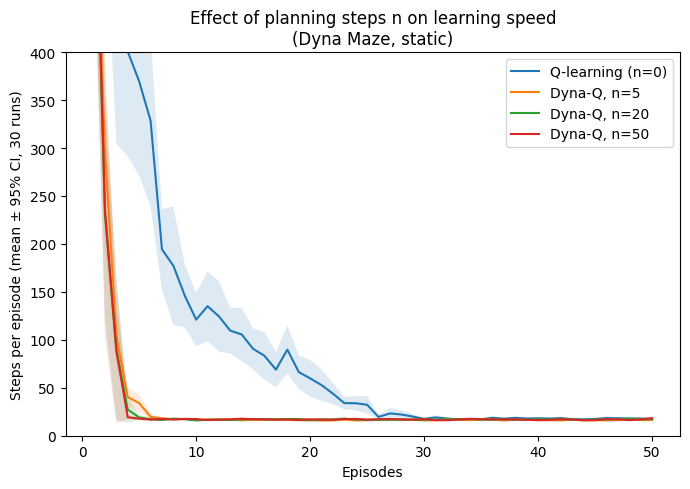

done
0 final 5-episode avg steps: 17.96
5 final 5-episode avg steps: 16.44
20 final 5-episode avg steps: 17.23
50 final 5-episode avg steps: 17.2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from envs import dyna_maze
from agents import QLearningAgent, DynaQAgent, run_episode

N_EPISODES = 50
N_RUNS = 30
PLANNING_STEPS = [0, 5, 20, 50]

raw = {n: np.zeros((N_RUNS, N_EPISODES)) for n in PLANNING_STEPS}

for n in PLANNING_STEPS:
    for run in range(N_RUNS):
        env = dyna_maze()
        if n == 0:
            agent = QLearningAgent(env.n_states, env.n_actions, alpha=0.1, gamma=0.95,
                                    epsilon=0.1, seed=run)
        else:
            agent = DynaQAgent(env.n_states, env.n_actions, planning_steps=n,
                                alpha=0.1, gamma=0.95, epsilon=0.1, seed=run)
        for ep in range(N_EPISODES):
            steps = run_episode(env, agent, is_dyna=(n != 0))
            raw[n][run, ep] = steps

plt.figure(figsize=(7, 5))
for n in PLANNING_STEPS:
    mean = raw[n].mean(axis=0)
    se = raw[n].std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    x = np.arange(1, N_EPISODES + 1)
    label = "Q-learning (n=0)" if n == 0 else f"Dyna-Q, n={n}"
    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - 1.96 * se, mean + 1.96 * se, alpha=0.15)
plt.xlabel("Episodes")
plt.ylabel("Steps per episode (mean \u00B1 95% CI, 30 runs)")
plt.title("Effect of planning steps n on learning speed\n(Dyna Maze, static)")
plt.ylim(0, 400)
plt.legend()
plt.tight_layout()
plt.savefig("figs/exp1_planning_steps.png", dpi=150)
plt.show()
print("done")
for n in PLANNING_STEPS:
    m = raw[n][:, -5:].mean()
    print(n, "final 5-episode avg steps:", round(m, 2))


# Blocking Maze

done
Q-learning final cumulative reward (mean): 5.5
Dyna-Q (n=5) final cumulative reward (mean): 73.93
Dyna-Q+ (n=5) final cumulative reward (mean): 96.9


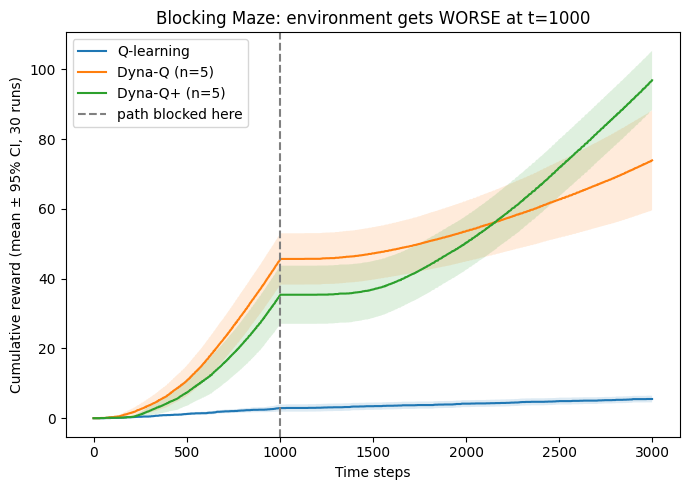

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from envs import blocking_maze
from agents import QLearningAgent, DynaQAgent, DynaQPlusAgent, run_continuing

TOTAL_STEPS = 3000
N_RUNS = 30
PLANNING = 5
ALPHA = 1.0
KAPPA = 1e-4  # tuned separately for this environment; see hyperparameter sweep

agents_spec = {
    "Q-learning": lambda ns, na, seed: (QLearningAgent(ns, na, alpha=ALPHA, seed=seed), False),
    "Dyna-Q (n=5)": lambda ns, na, seed: (DynaQAgent(ns, na, planning_steps=PLANNING, alpha=ALPHA, seed=seed), True),
    "Dyna-Q+ (n=5)": lambda ns, na, seed: (DynaQPlusAgent(ns, na, planning_steps=PLANNING, kappa=KAPPA, alpha=ALPHA, seed=seed), True),
}

raw = {name: np.zeros((N_RUNS, TOTAL_STEPS)) for name in agents_spec}

for name, factory in agents_spec.items():
    for run in range(N_RUNS):
        env = blocking_maze()
        agent, is_dyna = factory(env.n_states, env.n_actions, run)
        raw[name][run] = run_continuing(env, agent, is_dyna, TOTAL_STEPS)

plt.figure(figsize=(7, 5))
for name in agents_spec:
    mean = raw[name].mean(axis=0)
    se = raw[name].std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    x = np.arange(TOTAL_STEPS)
    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - 1.96 * se, mean + 1.96 * se, alpha=0.15)
plt.axvline(x=1000, color="gray", linestyle="--", label="path blocked here")
plt.xlabel("Time steps")
plt.ylabel("Cumulative reward (mean \u00B1 95% CI, 30 runs)")
plt.title("Blocking Maze: environment gets WORSE at t=1000")
plt.legend()
plt.tight_layout()
plt.savefig("figs/exp2_blocking_maze.png", dpi=150)
plt.show()
print("done")
for name in agents_spec:
    print(name, "final cumulative reward (mean):", round(raw[name][:, -1].mean(), 2))


# Shortcut Maze

Part A done
  Q-learning final cumulative reward (mean): 108.57
  Dyna-Q (n=5) final cumulative reward (mean): 268.53
  Dyna-Q+ (n=5) final cumulative reward (mean): 195.5


/tmp/ipykernel_2029/3661004653.py:97: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=labels, showmeans=True)


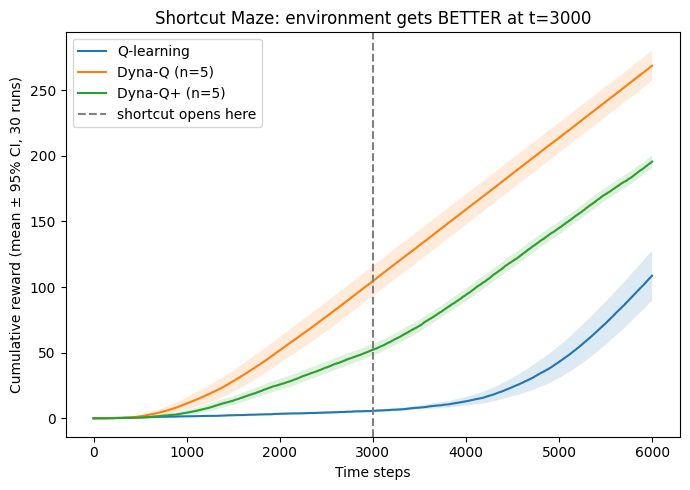

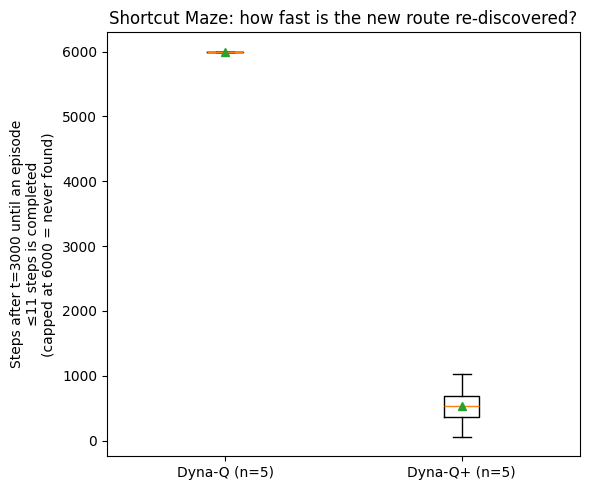

Part B done
  Dyna-Q (n=5) found in 0/30 runs, median steps-to-find: 6000
  Dyna-Q+ (n=5) found in 30/30 runs, median steps-to-find: 531


In [ ]:
  import numpy as np
import matplotlib.pyplot as plt
from envs import shortcut_maze
from agents import QLearningAgent, DynaQAgent, DynaQPlusAgent, run_continuing

TOTAL_STEPS = 6000
N_RUNS = 30
PLANNING = 5
ALPHA = 1.0
KAPPA = 2e-3  # tuned for this environment: reveals the shortcut-discovery gap
              # (see hyperparameter sweep for why this differs from the Blocking Maze's 1e-4)

# ---------- Part A: cumulative reward curves ----------
agents_spec = {
    "Q-learning": lambda ns, na, seed: (QLearningAgent(ns, na, alpha=ALPHA, seed=seed), False),
    "Dyna-Q (n=5)": lambda ns, na, seed: (DynaQAgent(ns, na, planning_steps=PLANNING, alpha=ALPHA, seed=seed), True),
    "Dyna-Q+ (n=5)": lambda ns, na, seed: (DynaQPlusAgent(ns, na, planning_steps=PLANNING, kappa=KAPPA, alpha=ALPHA, seed=seed), True),
}

raw = {name: np.zeros((N_RUNS, TOTAL_STEPS)) for name in agents_spec}
for name, factory in agents_spec.items():
    for run in range(N_RUNS):
        env = shortcut_maze()
        agent, is_dyna = factory(env.n_states, env.n_actions, run)
        raw[name][run] = run_continuing(env, agent, is_dyna, TOTAL_STEPS)

plt.figure(figsize=(7, 5))
for name in agents_spec:
    mean = raw[name].mean(axis=0)
    se = raw[name].std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    x = np.arange(TOTAL_STEPS)
    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - 1.96 * se, mean + 1.96 * se, alpha=0.15)
plt.axvline(x=3000, color="gray", linestyle="--", label="shortcut opens here")
plt.xlabel("Time steps")
plt.ylabel("Cumulative reward (mean \u00B1 95% CI, 30 runs)")
plt.title("Shortcut Maze: environment gets BETTER at t=3000")
plt.legend()
plt.tight_layout()
plt.savefig("figs/exp3a_shortcut_reward.png", dpi=150)
plt.show()
print("Part A done")
for name in agents_spec:
    print(" ", name, "final cumulative reward (mean):", round(raw[name][:, -1].mean(), 2))


# ---------- Part B: time-to-discover-the-shortcut metric ----------
# BFS-confirmed optimal path lengths: 16 steps before the shortcut opens, 10 after.
# "Discovery" = first post-change episode completed in <=11 steps (i.e. essentially
# the new optimal route, allowing for a single off-policy epsilon deviation).
SHORTCUT_THRESH = 11
CHANGE_STEP = 3000
DISC_HORIZON = 6000  # steps after the change we allow for discovery


def run_track_discovery(env, agent, is_dyna, total_steps, shortcut_thresh, change_step):
    s = env.reset()
    s_idx = env.state_index(s)
    ep_start = 0
    discovery_t = None
    for t in range(total_steps):
        a = agent.act(s_idx)
        s2, r, done, timeout = env.step(a)
        s2_idx = env.state_index(s2)
        agent.update(s_idx, a, r, s2_idx, done)
        if is_dyna:
            agent.update_model(s_idx, a, r, s2_idx)
            if hasattr(agent, "step_time"):
                agent.step_time()
            agent.plan()
        if done or timeout:
            ep_len = t - ep_start + 1
            if t >= change_step and done and ep_len <= shortcut_thresh and discovery_t is None:
                discovery_t = t - change_step
            s = env.reset()
            s_idx = env.state_index(s)
            ep_start = t + 1
        else:
            s_idx = s2_idx
    return discovery_t


disc_agents = {
    "Dyna-Q (n=5)": lambda ns, na, seed: DynaQAgent(ns, na, planning_steps=PLANNING, alpha=ALPHA, epsilon=0.1, seed=seed),
    "Dyna-Q+ (n=5)": lambda ns, na, seed: DynaQPlusAgent(ns, na, planning_steps=PLANNING, kappa=KAPPA, alpha=ALPHA, epsilon=0.1, seed=seed),
}
disc_results = {name: [] for name in disc_agents}
for name, factory in disc_agents.items():
    for run in range(N_RUNS):
        env = shortcut_maze()
        agent = factory(env.n_states, env.n_actions, run)
        d = run_track_discovery(env, agent, True, CHANGE_STEP + DISC_HORIZON, SHORTCUT_THRESH, CHANGE_STEP)
        disc_results[name].append(d if d is not None else DISC_HORIZON)  # censored at horizon

plt.figure(figsize=(6, 5))
labels = list(disc_agents.keys())
data = [disc_results[name] for name in labels]
bp = plt.boxplot(data, labels=labels, showmeans=True)
plt.ylabel(f"Steps after t=3000 until an episode\n\u2264{SHORTCUT_THRESH} steps is completed\n(capped at {DISC_HORIZON} = never found)")
plt.title("Shortcut Maze: how fast is the new route re-discovered?")
plt.tight_layout()
plt.savefig("figs/exp3b_shortcut_discovery.png", dpi=150)
plt.show()
print("Part B done")
for name in disc_agents:
    vals = np.array(disc_results[name])
    n_found = (vals < DISC_HORIZON).sum()
    print(" ", name, f"found in {n_found}/{N_RUNS} runs, median steps-to-find:", int(np.median(vals)))


# Flickering Maze

done
  Q-learning final cumulative reward (mean): 420.0
  Dyna-Q (n=5) final cumulative reward (mean): 572.03
  Dyna-Q (n=20) final cumulative reward (mean): 577.33


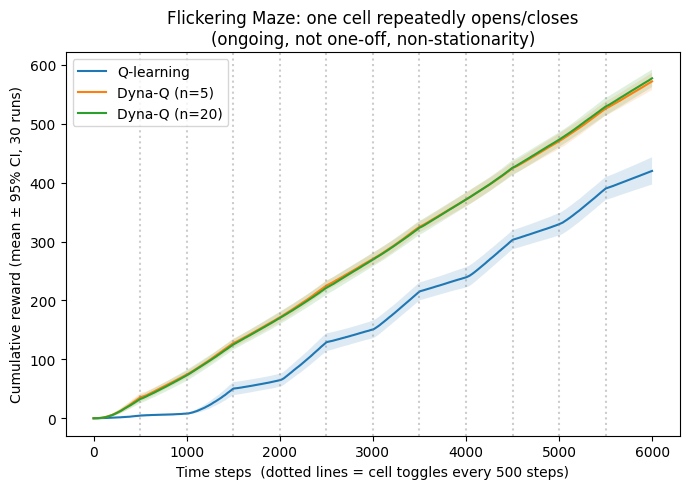

In [ ]:
"""
Flickering Maze: a genuinely different kind of non-stationarity from the
Blocking/Shortcut mazes above. Instead of ONE change partway through the
run, a single interior cell periodically opens and closes throughout the
ENTIRE run (every 500 steps). The shortest path length alternates between
5 (cell open) and 9 (cell closed) steps. This tests whether an agent's
planning helps it track an environment that never settles down, rather
than adapt once to a single change.
"""

import numpy as np
import matplotlib.pyplot as plt
from envs import flickering_maze
from agents import QLearningAgent, DynaQAgent, run_continuing

TOTAL_STEPS = 6000
N_RUNS = 30
PLANNING = 5
ALPHA = 1.0

agents_spec = {
    "Q-learning": lambda ns, na, seed: (QLearningAgent(ns, na, alpha=ALPHA, seed=seed), False),
    "Dyna-Q (n=5)": lambda ns, na, seed: (DynaQAgent(ns, na, planning_steps=PLANNING, alpha=ALPHA, seed=seed), True),
    "Dyna-Q (n=20)": lambda ns, na, seed: (DynaQAgent(ns, na, planning_steps=20, alpha=ALPHA, seed=seed), True),
}

raw = {name: np.zeros((N_RUNS, TOTAL_STEPS)) for name in agents_spec}
for name, factory in agents_spec.items():
    for run in range(N_RUNS):
        env = flickering_maze()
        agent, is_dyna = factory(env.n_states, env.n_actions, run)
        raw[name][run] = run_continuing(env, agent, is_dyna, TOTAL_STEPS)

plt.figure(figsize=(7, 5))
for name in agents_spec:
    mean = raw[name].mean(axis=0)
    se = raw[name].std(axis=0, ddof=1) / np.sqrt(N_RUNS)
    x = np.arange(TOTAL_STEPS)
    plt.plot(x, mean, label=name)
    plt.fill_between(x, mean - 1.96 * se, mean + 1.96 * se, alpha=0.15)
for t in range(500, TOTAL_STEPS, 500):
    plt.axvline(x=t, color="gray", linestyle=":", alpha=0.4)
plt.xlabel("Time steps  (dotted lines = cell toggles every 500 steps)")
plt.ylabel("Cumulative reward (mean \u00B1 95% CI, 30 runs)")
plt.title("Flickering Maze: one cell repeatedly opens/closes\n(ongoing, not one-off, non-stationarity)")
plt.legend()
plt.tight_layout()
plt.savefig("figs/exp4_flickering_maze.png", dpi=150)
plt.show()
print("done")
for name in agents_spec:
    print(" ", name, "final cumulative reward (mean):", round(raw[name][:, -1].mean(), 2))

# Also report steps-per-episode in the LAST 1000 steps (steady-state adaptation quality)


# Make Maze figure

done


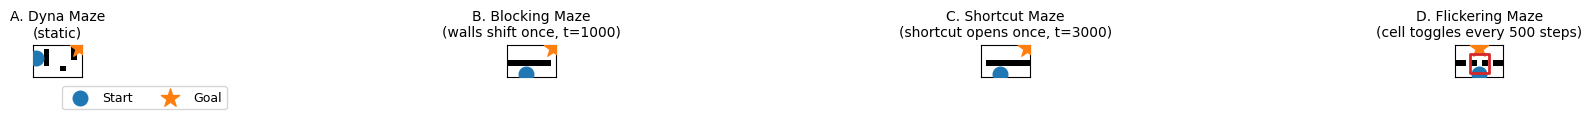

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from envs import dyna_maze, blocking_maze, shortcut_maze, flickering_maze

def draw(ax, env, title, walls, start, goal, toggle=None):
    grid = np.zeros((env.height, env.width))
    for (r, c) in walls:
        grid[r, c] = 1
    ax.imshow(grid, cmap="Greys", vmin=0, vmax=1)
    if toggle is not None:
        ax.scatter([toggle[1]], [toggle[0]], marker="s", s=180, facecolors="none",
                   edgecolors="tab:red", linewidths=2, zorder=4)
    ax.scatter([start[1]], [start[0]], marker="o", s=110, color="tab:blue", zorder=3, label="Start")
    ax.scatter([goal[1]], [goal[0]], marker="*", s=190, color="tab:orange", zorder=3, label="Goal")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

env = dyna_maze()
draw(axes[0], env, "A. Dyna Maze\n(static)", env.walls_before, env.start, env.goal)

env = blocking_maze()
draw(axes[1], env, "B. Blocking Maze\n(walls shift once, t=1000)", env.walls_before, env.start, env.goal)

env = shortcut_maze()
draw(axes[2], env, "C. Shortcut Maze\n(shortcut opens once, t=3000)", env.walls_before, env.start, env.goal)

env = flickering_maze()
draw(axes[3], env, "D. Flickering Maze\n(cell toggles every 500 steps)", env.walls_before, env.start, env.goal,
     toggle=env.toggle_cell)

axes[0].legend(loc="upper center", bbox_to_anchor=(2.3, -0.08), ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("figs/maze_layouts.png", dpi=150, bbox_inches="tight")
plt.show()
print("done")


# Hyperparam_sweep

In [ ]:
import numpy as np
from envs import blocking_maze, shortcut_maze
from agents import DynaQAgent, DynaQPlusAgent, run_continuing

N_RUNS = 15

print("=== Step size (alpha) sensitivity: Dyna-Q, n=5, Blocking Maze, final cumulative reward ===")
for alpha in [0.1, 0.3, 0.5, 1.0]:
    vals = []
    for seed in range(N_RUNS):
        env = blocking_maze()
        agent = DynaQAgent(env.n_states, env.n_actions, planning_steps=5, alpha=alpha, seed=seed)
        cum = run_continuing(env, agent, True, 3000)
        vals.append(cum[-1])
    print(f"  alpha={alpha:<4}  mean={np.mean(vals):6.1f}  std={np.std(vals):5.1f}")

print()
print("=== Exploration bonus (kappa) sensitivity: Dyna-Q+, n=5, alpha=1.0, Blocking Maze ===")
for kappa in [1e-5, 1e-4, 1e-3, 1e-2]:
    vals = []
    for seed in range(N_RUNS):
        env = blocking_maze()
        agent = DynaQPlusAgent(env.n_states, env.n_actions, planning_steps=5, alpha=1.0, kappa=kappa, seed=seed)
        cum = run_continuing(env, agent, True, 3000)
        vals.append(cum[-1])
    print(f"  kappa={kappa:<8}  mean={np.mean(vals):6.1f}  std={np.std(vals):5.1f}")

print()
print("=== Exploration bonus (kappa) sensitivity: Dyna-Q+, n=5, alpha=1.0, Shortcut Maze (6000 steps) ===")
for kappa in [1e-4, 1e-3, 2e-3, 5e-3, 1e-2]:
    vals = []
    for seed in range(N_RUNS):
        env = shortcut_maze()
        agent = DynaQPlusAgent(env.n_states, env.n_actions, planning_steps=5, alpha=1.0, kappa=kappa, seed=seed)
        cum = run_continuing(env, agent, True, 6000)
        vals.append(cum[-1])
    print(f"  kappa={kappa:<8}  mean={np.mean(vals):6.1f}  std={np.std(vals):5.1f}")

print()
print("=== Planning steps (n) sensitivity: Dyna-Q, alpha=1.0, Blocking Maze ===")
for n in [1, 5, 10, 20, 50]:
    vals = []
    for seed in range(N_RUNS):
        env = blocking_maze()
        agent = DynaQAgent(env.n_states, env.n_actions, planning_steps=n, alpha=1.0, seed=seed)
        cum = run_continuing(env, agent, True, 3000)
        vals.append(cum[-1])
    print(f"  n={n:<4}  mean={np.mean(vals):6.1f}  std={np.std(vals):5.1f}")


=== Step size (alpha) sensitivity: Dyna-Q, n=5, Blocking Maze, final cumulative reward ===
  alpha=0.1   mean=  46.7  std= 17.2
  alpha=0.3   mean=  60.9  std= 28.6
  alpha=0.5   mean=  74.7  std= 33.0
  alpha=1.0   mean=  63.9  std= 35.7

=== Exploration bonus (kappa) sensitivity: Dyna-Q+, n=5, alpha=1.0, Blocking Maze ===
  kappa=1e-05     mean= 103.3  std= 25.0
  kappa=0.0001    mean= 102.3  std= 24.7
  kappa=0.001     mean=  97.1  std= 21.1
  kappa=0.01      mean=   3.7  std=  1.2

=== Exploration bonus (kappa) sensitivity: Dyna-Q+, n=5, alpha=1.0, Shortcut Maze (6000 steps) ===
  kappa=0.0001    mean= 271.1  std= 27.0
  kappa=0.001     mean= 295.9  std= 26.0
  kappa=0.002     mean= 196.3  std= 15.4
  kappa=0.005     mean=   6.5  std=  1.5
  kappa=0.01      mean=   5.7  std=  1.8

=== Planning steps (n) sensitivity: Dyna-Q, alpha=1.0, Blocking Maze ===
  n=1     mean=  43.7  std= 22.3
  n=5     mean=  63.9  std= 35.7
  n=10    mean=  86.0  std= 44.2
  n=20    mean=  79.1  std= 40.7